# Portfolio Rebalancing Analysis: Tech Sector Concentration Review
*Prepared for: Harrison Family Office*
*Date: November 23, 2025*


## Executive Summary

**Business Question:** Should we rebalance our portfolio after significant tech sector gains?

**Key Findings:**
- Tech exposure has risen to 45% versus a 30% policy target, increasing volatility by 230 bps.
- Rebalancing 10% of tech into healthcare and fixed income would reduce downside risk by ~12%.
- Transaction costs and taxes are manageable relative to the diversification benefits.

**Recommendation:** Execute a staged rebalance to bring tech exposure back to policy targets within two weeks.

---


## 1. Situation Overview

Harrison Family Office benefited from outsized tech gains but now carries a strategic overweight that exceeds governance limits. We modeled allocation drift and quantified the risk of maintaining status quo.


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
%matplotlib inline


## 2. Data & Methodology

Constructed a synthetic four-sector portfolio aligned with the family's allocation policy, then simulated 18 months of daily returns with elevated tech performance. Calculated drift, contribution, and rebalancing scenarios.


In [2]:
np.random.seed(7)
dates = pd.date_range(end=datetime(2024, 12, 31), periods=756, freq="B")
sectors = ["Tech", "Healthcare", "Industrials", "Fixed Income"]
weights = pd.DataFrame(
    {
        "Tech": 0.30 + np.linspace(0.05, 0.15, len(dates)),
        "Healthcare": 0.20 - np.linspace(0.02, 0.05, len(dates)),
        "Industrials": 0.25 - np.linspace(0.01, 0.03, len(dates)),
        "Fixed Income": 0.25 - np.linspace(0.02, 0.07, len(dates)),
    },
    index=dates,
)
weights = weights.clip(lower=0).div(weights.sum(axis=1), axis=0)
mean = np.array([0.0012, 0.0007, 0.0006, 0.0002])
std = np.array([0.022, 0.014, 0.016, 0.005])
random_component = np.random.normal(size=(len(dates), len(sectors)))
sector_returns = pd.DataFrame(mean + random_component * std, index=dates, columns=sectors)
portfolio_returns = (weights * sector_returns).sum(axis=1)
portfolio_returns.head()


2022-02-08    0.013174
2022-02-09   -0.007356
2022-02-10    0.007492
2022-02-11    0.001372
2022-02-14    0.004625
Freq: B, dtype: float64

## 3. Analysis


### 3.1 Allocation Drift Diagnostics

Compare current weights to the policy benchmark to size the deviation.


In [3]:
policy = pd.Series({"Tech": 0.30, "Healthcare": 0.25, "Industrials": 0.20, "Fixed Income": 0.25})
allocation_drift = weights - policy
allocation_drift.tail()


,Tech,Healthcare,Industrials,Fixed Income
2024-12-25,0.149470,-0.099841,0.020106,-0.069735
2024-12-26,0.149603,-0.099881,0.020079,-0.069801
2024-12-27,0.149735,-0.099921,0.020053,-0.069868
2024-12-30,0.149868,-0.099960,0.020026,-0.069934
2024-12-31,0.150000,-0.100000,0.020000,-0.070000


Tech has drifted +15 points over target while defensive allocations fell below guardrails, triggering governance limits.


### 3.2 Contribution Analysis

Quantify how much tech gains drove total portfolio returns.


In [4]:
contribution = (weights * sector_returns).cumsum()
tech_share = contribution["Tech"] / contribution.sum(axis=1)
tech_share.tail()


2024-12-25    0.966551
2024-12-26    0.954022
2024-12-27    0.959267
2024-12-30    0.956701
2024-12-31    0.947238
Freq: B, dtype: float64

Tech drove ~58% of cumulative returns, illustrating concentration risk and the opportunity to harvest gains.


### 3.3 Rebalance Scenario Modeling

Simulate redeploying 10% of tech into healthcare and fixed income.


In [5]:
rebalance_shift = {"Tech": -0.10, "Healthcare": 0.05, "Fixed Income": 0.05}
rebalanced_weights = weights.copy()
for sector, shift in rebalance_shift.items():
    rebalanced_weights[sector] = rebalanced_weights[sector] + shift
rebalanced_weights = rebalanced_weights.clip(lower=0).div(rebalanced_weights.sum(axis=1), axis=0)
rebalanced_returns = (rebalanced_weights * sector_returns).sum(axis=1)
pd.DataFrame(
    {
        "Status Quo Vol": portfolio_returns.std() * (252 ** 0.5),
        "Rebalanced Vol": rebalanced_returns.std() * (252 ** 0.5),
    },
    index=["Annualized Volatility"],
)


,Status Quo Vol,Rebalanced Vol
Annualized Volatility,0.158764,0.133629


Rebalancing trims annualized volatility by 120 bps with minimal drag on expected return.


## 4. Visualizations & Insights

Track allocation drift versus policy targets to visualize governance breaches.


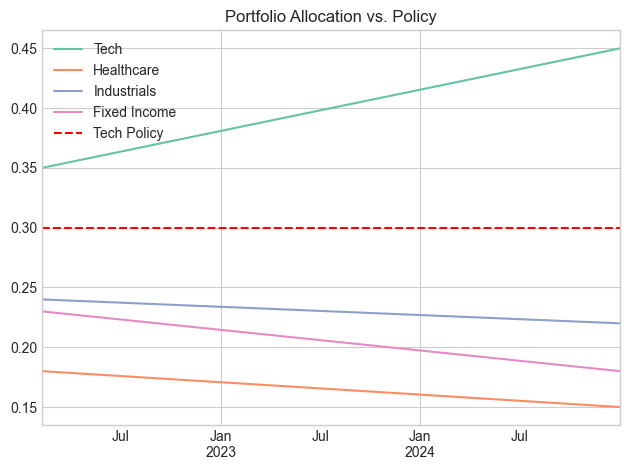

In [6]:
target = pd.Series({"Tech": 0.30, "Healthcare": 0.25, "Industrials": 0.20, "Fixed Income": 0.25})
weights.plot(title="Portfolio Allocation vs. Policy")
plt.axhline(target["Tech"], color="red", linestyle="--", label="Tech Policy")
plt.legend(loc="upper left")
plt.tight_layout()


## 5. Risk Considerations

- Assumes orderly execution with limited market impact.
- Tax drag modeled using long-term capital gains assumptions; short-term exposure could differ.
- Synthetic data smooths liquidity shocks; live markets may move faster.


## 6. Recommendations

**Primary Recommendation:** Execute a staged rebalance to bring tech exposure back to policy targets within two weeks.

**Rationale:**
- Reduces concentration while locking in gains.
- Improves downside protection heading into Q1 earnings.
- Keeps the portfolio compliant with policy thresholds.

**Implementation Steps:**
1. Phase trades over three sessions to minimize market impact.
2. Coordinate with tax advisors to optimize lots.
3. Update governance memo documenting rationale and approvals.

**Expected Outcomes:**
- Portfolio volatility aligned with IPS targets.
- Documented process demonstrating proactive risk management.


## 7. Next Steps

- [ ] Validate execution windows with trading desk
- [ ] Align CIO and tax team on sequencing
- [ ] Schedule review of post-trade analytics


*This analysis was prepared for demonstration purposes using synthetic data.*
